In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [3]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)

c:\Users\Prachi Jadhav\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training images: (50000, 32, 32, 3)
Testing images : (10000, 32, 32, 3)


In [4]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [5]:
NUM_CLASSES=10
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print("Label shape:", y_train_cat.shape)

Label shape: (50000, 10)


In [6]:
BATCH_SIZE = 32
def create_dataset(x, y, preprocess_function=None, training=False):
    def preprocess(image, label):
        image = tf.cast(image, tf.float32)
        image = tf.image.resize(
            image,
            (IMAGE_SIZE, IMAGE_SIZE)
        )
        if preprocess_function is not None:
            image = preprocess_function(image)

        return image, label

    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    if training:
        dataset = dataset.shuffle(10000)

    dataset = dataset.map(
        preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


In [7]:
def create_vgg16_model():

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False
    model = models.Sequential([
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            256,
            activation='relu'
        ),

        layers.Dropout(0.5),

        layers.Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']
    )

    return model



In [8]:
def create_resnet50_model():

    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            256,
            activation='relu'
        ),

        layers.Dropout(0.5),

        layers.Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']
    )

    return model


In [9]:
def create_efficientnet_model():

    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            256,
            activation='relu'
        ),

        layers.Dropout(0.5),

        layers.Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']
    )

    return model

In [10]:
def create_alexnet_model():

    model = models.Sequential([

        layers.Input(
            shape=(224, 224, 3)
        ),
        layers.Conv2D(
            96,
            kernel_size=(11, 11),
            strides=4,
            activation='relu'
        ),

        layers.MaxPooling2D(
            pool_size=(3, 3),
            strides=2
        ),
        layers.Conv2D(
            256,
            kernel_size=(5, 5),
            padding='same',
            activation='relu'
        ),

        layers.MaxPooling2D(
            pool_size=(3, 3),
            strides=2
        ),
        layers.Conv2D(
            384,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),
        layers.Conv2D(
            384,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),
        layers.Conv2D(
            256,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),

        layers.MaxPooling2D(
            pool_size=(3, 3),
            strides=2
        ),
        layers.Flatten(),

        layers.Dense(
            4096,
            activation='relu'
        ),

        layers.Dropout(0.5),

        layers.Dense(
            4096,
            activation='relu'
        ),

        layers.Dropout(0.5),
        layers.Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0001
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']
    )

    return model


In [11]:
print("\nCreating VGG16...")
vgg_model = create_vgg16_model()

print("\nCreating ResNet50...")
resnet_model = create_resnet50_model()

print("\nCreating EfficientNetB0...")
efficientnet_model = create_efficientnet_model()

print("\nCreating AlexNet...")
alexnet_model = create_alexnet_model()



Creating VGG16...

Creating ResNet50...

Creating EfficientNetB0...

Creating AlexNet...


In [12]:
print("\n================ VGG16 =================")
vgg_model.summary()

print("\n================ RESNET50 =================")
resnet_model.summary()

print("\n================ EFFICIENTNETB0 =================")
efficientnet_model.summary()

print("\n================ ALEXNET =================")
alexnet_model.summary()



================ VGG16 =================


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,787,978 (178.48 MB)

 Trainable params: 46,787,978 (178.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
IMAGE_SIZE = 224
# VGG16 preprocessing
train_vgg = create_dataset(
    x_train,
    y_train_cat,
    vgg_preprocess,
    training=True
)

test_vgg = create_dataset(
    x_test,
    y_test_cat,
    vgg_preprocess
)


# ResNet50 preprocessing
train_resnet = create_dataset(
    x_train,
    y_train_cat,
    resnet_preprocess,
    training=True
)

test_resnet = create_dataset(
    x_test,
    y_test_cat,
    resnet_preprocess
)


# EfficientNet preprocessing
train_efficientnet = create_dataset(
    x_train,
    y_train_cat,
    efficientnet_preprocess,
    training=True
)

test_efficientnet = create_dataset(
    x_test,
    y_test_cat,
    efficientnet_preprocess
)


def alexnet_preprocess(image):

    image = image / 255.0

    return image


train_alexnet = create_dataset(
    x_train,
    y_train_cat,
    alexnet_preprocess,
    training=True
)

test_alexnet = create_dataset(
    x_test,
    y_test_cat,
    alexnet_preprocess
)
def alexnet_preprocess(image):

    image = image / 255.0

    return image


train_alexnet = create_dataset(
    x_train,
    y_train_cat,
    alexnet_preprocess,
    training=True
)

test_alexnet = create_dataset(
    x_test,
    y_test_cat,
    alexnet_preprocess
)


In [ ]:


print("\n======================================")
print("TRAINING VGG16")
print("======================================")

history_vgg = vgg_model.fit(
    train_vgg,
    validation_data=test_vgg,
    epochs=2
)


TRAINING VGG16
Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35594s 23s/step - accuracy: 0.7438 - loss: 0.7596 - val_accuracy: 0.8340 - val_loss: 0.4961
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55243s 35s/step - accuracy: 0.8119 - loss: 0.5475 - val_accuracy: 0.8488 - val_loss: 0.4438


In [16]:
history_resnet = resnet_model.fit(
    train_resnet,
    validation_data=test_resnet,
    epochs=2
)

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7402s 5s/step - accuracy: 0.8321 - loss: 0.5017 - val_accuracy: 0.8769 - val_loss: 0.3442
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11060s 7s/step - accuracy: 0.8706 - loss: 0.3771 - val_accuracy: 0.8950 - val_loss: 0.3070


In [17]:
history_efficientnet = efficientnet_model.fit(
    train_efficientnet,
    validation_data=test_efficientnet,
    epochs=2
)

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1422s 900ms/step - accuracy: 0.8446 - loss: 0.4563 - val_accuracy: 0.8971 - val_loss: 0.3093
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2093s 1s/step - accuracy: 0.8799 - loss: 0.3473 - val_accuracy: 0.8976 - val_loss: 0.2968


In [18]:
history_alexnet = alexnet_model.fit(
    train_alexnet,
    validation_data=test_alexnet,
    epochs=2
)

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4980s 3s/step - accuracy: 0.4244 - loss: 1.5614 - val_accuracy: 0.5781 - val_loss: 1.1960
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4627s 3s/step - accuracy: 0.6455 - loss: 1.0091 - val_accuracy: 0.6857 - val_loss: 0.9147


In [19]:
vgg_loss, vgg_accuracy = vgg_model.evaluate(
    test_vgg
)

print("VGG16 Test Accuracy:", vgg_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2414s 8s/step - accuracy: 0.8488 - loss: 0.4438
VGG16 Test Accuracy: 0.848800003528595


In [20]:
resnet_loss, resnet_accuracy = resnet_model.evaluate(
    test_resnet
)

print("ResNet50 Test Accuracy:", resnet_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1146s 4s/step - accuracy: 0.8950 - loss: 0.3070
ResNet50 Test Accuracy: 0.8949999809265137


In [21]:
efficientnet_loss, efficientnet_accuracy = efficientnet_model.evaluate(
    test_efficientnet
)

print("EfficientNetB0 Test Accuracy:", efficientnet_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 492s 2s/step - accuracy: 0.8976 - loss: 0.2968
EfficientNetB0 Test Accuracy: 0.897599995136261


In [22]:
alexnet_loss, alexnet_accuracy = alexnet_model.evaluate(
    test_alexnet
)

print("AlexNet Test Accuracy:", alexnet_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 257s 820ms/step - accuracy: 0.6857 - loss: 0.9147
AlexNet Test Accuracy: 0.685699999332428


In [23]:
results = pd.DataFrame({

    'Model': [
        'AlexNet',
        'VGG16',
        'ResNet50',
        'EfficientNetB0'
    ],

    'Test Accuracy': [
        alexnet_accuracy,
        vgg_accuracy,
        resnet_accuracy,
        efficientnet_accuracy
    ],

    'Test Loss': [
        alexnet_loss,
        vgg_loss,
        resnet_loss,
        efficientnet_loss
    ]
})

print(results)

            Model  Test Accuracy  Test Loss
0         AlexNet         0.6857   0.914675
1           VGG16         0.8488   0.443790
2        ResNet50         0.8950   0.306957
3  EfficientNetB0         0.8976   0.296848


In [25]:
best_model = results.loc[
    results['Test Accuracy'].idxmax()
]

print("\nBest Performing Model:")
print(best_model)


Best Performing Model:
Model            EfficientNetB0
Test Accuracy            0.8976
Test Loss              0.296848
Name: 3, dtype: object


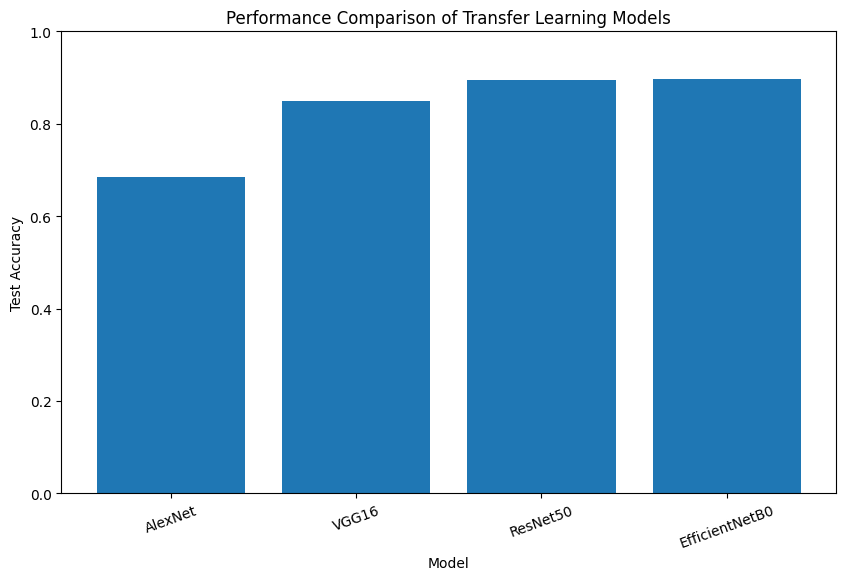

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    results['Model'],
    results['Test Accuracy']
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")

plt.title(
    "Performance Comparison of Transfer Learning Models"
)

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

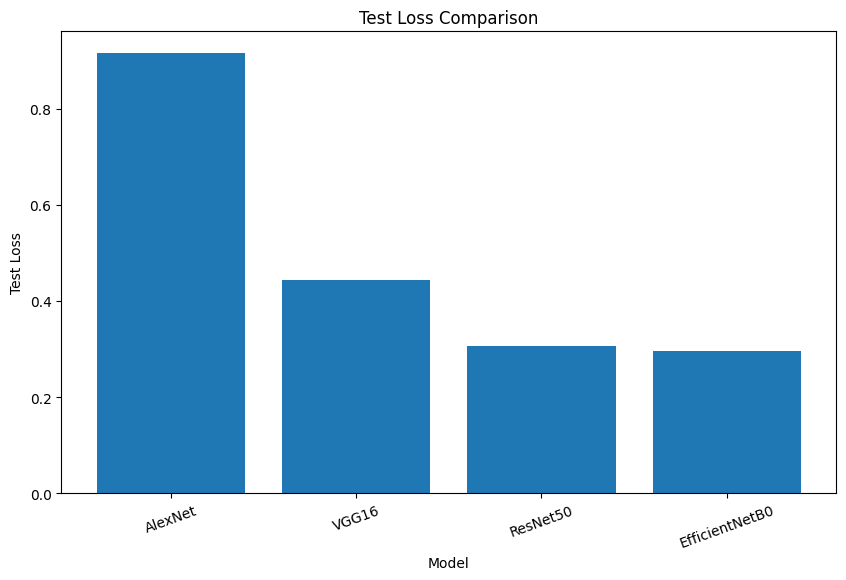

In [27]:
plt.figure(figsize=(10, 6))

plt.bar(
    results['Model'],
    results['Test Loss']
)

plt.xlabel("Model")
plt.ylabel("Test Loss")

plt.title(
    "Test Loss Comparison"
)

plt.xticks(rotation=20)

plt.show()

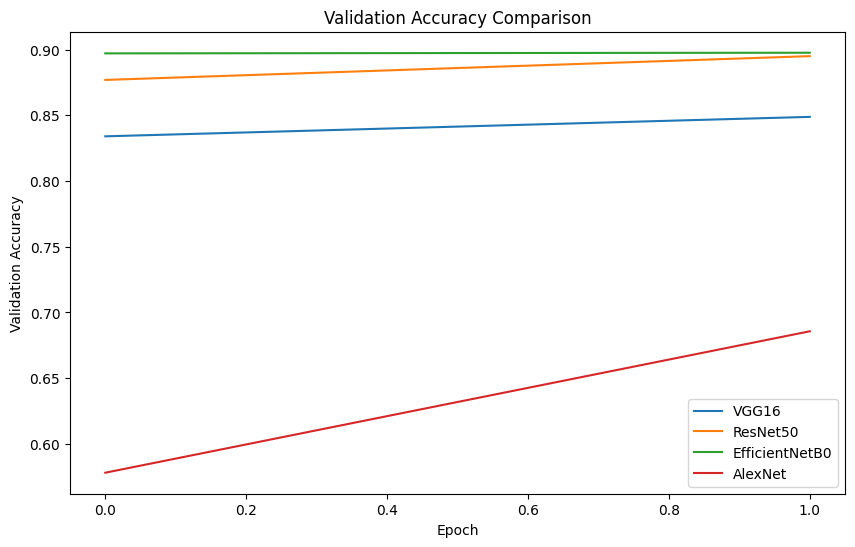

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_vgg.history['val_accuracy'],
    label='VGG16'
)

plt.plot(
    history_resnet.history['val_accuracy'],
    label='ResNet50'
)

plt.plot(
    history_efficientnet.history['val_accuracy'],
    label='EfficientNetB0'
)

plt.plot(
    history_alexnet.history['val_accuracy'],
    label='AlexNet'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title(
    "Validation Accuracy Comparison"
)

plt.legend()

plt.show()

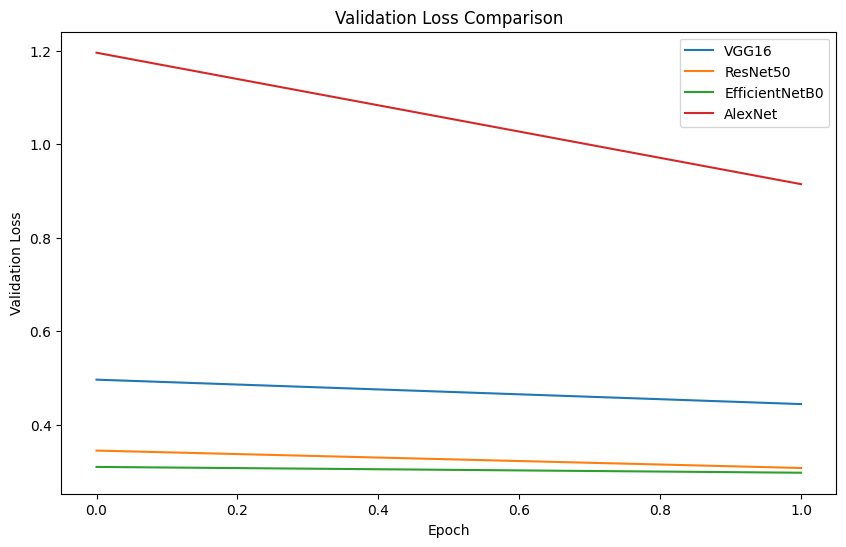

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_vgg.history['val_loss'],
    label='VGG16'
)

plt.plot(
    history_resnet.history['val_loss'],
    label='ResNet50'
)

plt.plot(
    history_efficientnet.history['val_loss'],
    label='EfficientNetB0'
)

plt.plot(
    history_alexnet.history['val_loss'],
    label='AlexNet'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Validation Loss Comparison"
)

plt.legend()

plt.show()

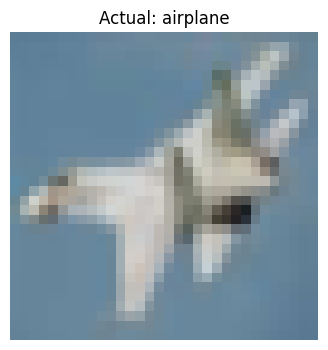

In [30]:
sample_index = 10

sample_image = x_test[sample_index]

plt.figure(figsize=(4, 4))

plt.imshow(sample_image)

plt.title(
    "Actual: " +
    class_names[y_test[sample_index][0]]
)

plt.axis('off')

plt.show()

In [31]:
image = tf.cast(
    sample_image,
    tf.float32
)

image = tf.image.resize(
    image,
    (224, 224)
)

image = tf.expand_dims(
    image,
    axis=0
)

In [32]:
vgg_image = vgg_preprocess(image)

vgg_prediction = vgg_model.predict(
    vgg_image,
    verbose=0
)

vgg_class = np.argmax(
    vgg_prediction
)

print(
    "VGG16 Prediction:",
    class_names[vgg_class]
)

VGG16 Prediction: airplane


In [33]:
resnet_image = resnet_preprocess(image)

resnet_prediction = resnet_model.predict(
    resnet_image,
    verbose=0
)

resnet_class = np.argmax(
    resnet_prediction
)

print(
    "ResNet50 Prediction:",
    class_names[resnet_class]
)

ResNet50 Prediction: airplane


In [34]:
efficientnet_image = efficientnet_preprocess(image)

efficientnet_prediction = efficientnet_model.predict(
    efficientnet_image,
    verbose=0
)

efficientnet_class = np.argmax(
    efficientnet_prediction
)

print(
    "EfficientNetB0 Prediction:",
    class_names[efficientnet_class]
)

EfficientNetB0 Prediction: airplane


In [35]:
alexnet_image = image / 255.0

alexnet_prediction = alexnet_model.predict(
    alexnet_image,
    verbose=0
)

alexnet_class = np.argmax(
    alexnet_prediction
)

print(
    "AlexNet Prediction:",
    class_names[alexnet_class]
)

AlexNet Prediction: airplane


In [36]:
print("\n======================================")
print("FINAL RESULTS")
print("======================================")

print(
    f"AlexNet       Accuracy: {alexnet_accuracy:.4f}"
)

print(
    f"VGG16         Accuracy: {vgg_accuracy:.4f}"
)

print(
    f"ResNet50      Accuracy: {resnet_accuracy:.4f}"
)

print(
    f"EfficientNet  Accuracy: {efficientnet_accuracy:.4f}"
)

print("\nBest Model:")
print(best_model['Model'])

print(
    f"Best Accuracy: "
    f"{best_model['Test Accuracy']:.4f}"
)


FINAL RESULTS
AlexNet       Accuracy: 0.6857
VGG16         Accuracy: 0.8488
ResNet50      Accuracy: 0.8950
EfficientNet  Accuracy: 0.8976

Best Model:
EfficientNetB0
Best Accuracy: 0.8976
